<a href="https://colab.research.google.com/github/mdrehantabish123/mdrehantabish123-Data_Science_Lab_SE_A_38/blob/main/experiment4(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Fair Coin Toss Simulation and Probability Analysis

This program simulates a fair coin toss experiment, calculates experimental probabilities, and visualizes the results. We will compare the observed frequencies and probabilities with the theoretical expectations of a fair coin (P(H) = 0.5, P(T) = 0.5).

Simulating 100000 fair coin tosses...

First 10 simulated outcomes: ['H' 'H' 'T' 'T' 'H' 'H' 'T' 'T' 'H' 'T']

Total Heads: 49905
Total Tails: 50095
Experimental Probability of Heads: 0.4990 (Theoretical: 0.5)
Experimental Probability of Tails: 0.5010 (Theoretical: 0.5)


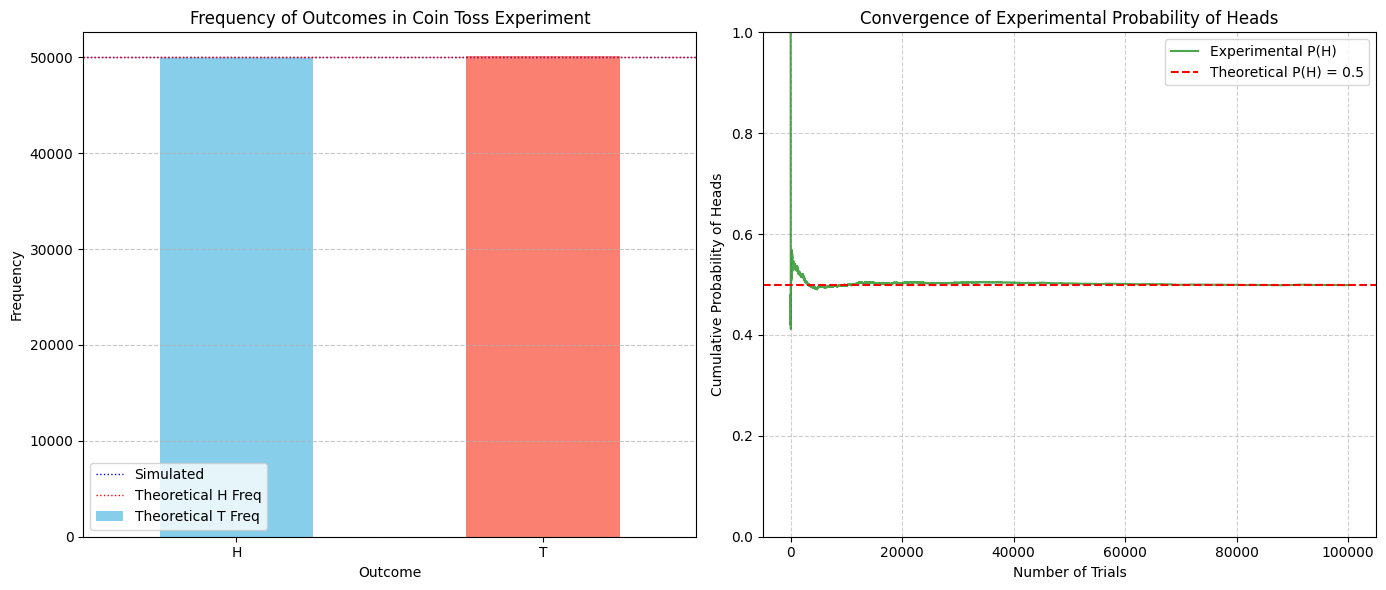

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Simulation Parameters ---
num_trials = 100000  # A large number of trials for better accuracy
print(f"Simulating {num_trials} fair coin tosses...")

# --- 2. Simulate Fair Coin Tosses ---
# Use np.random.choice to simulate coin tosses with equal probabilities (p=[0.5, 0.5])
possible_outcomes = ['H', 'T']
results = np.random.choice(possible_outcomes, size=num_trials, p=[0.5, 0.5])

print("\nFirst 10 simulated outcomes:", results[:10])

# --- 3. Calculate Experimental Probabilities ---
heads_count = np.sum(results == 'H')
tails_count = np.sum(results == 'T')

experimental_prob_heads = heads_count / num_trials
experimental_prob_tails = tails_count / num_trials

print(f"\nTotal Heads: {heads_count}")
print(f"Total Tails: {tails_count}")
print(f"Experimental Probability of Heads: {experimental_prob_heads:.4f} (Theoretical: 0.5)")
print(f"Experimental Probability of Tails: {experimental_prob_tails:.4f} (Theoretical: 0.5)")

# --- 4. Visualize Results ---
plt.figure(figsize=(14, 6))

# Subplot 1: Bar chart of Frequencies
plt.subplot(1, 2, 1)
outcomes_series = pd.Series(results)
frequency_counts = outcomes_series.value_counts().sort_index() # Sort to ensure consistent order (H, T)
frequency_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frequency of Outcomes in Coin Toss Experiment')
plt.xlabel('Outcome')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add theoretical probability lines
theoretical_heads_freq = num_trials * 0.5
theoretical_tails_freq = num_trials * 0.5
plt.axhline(y=theoretical_heads_freq, color='blue', linestyle=':', linewidth=1, label='Theoretical H Freq')
plt.axhline(y=theoretical_tails_freq, color='red', linestyle=':', linewidth=1, label='Theoretical T Freq')
plt.legend(['Simulated', 'Theoretical H Freq', 'Theoretical T Freq'])

# Subplot 2: Cumulative Probability of Heads (Law of Large Numbers)
plt.subplot(1, 2, 2)
cumulative_heads_indicator = (results == 'H').astype(int)
cumulative_heads_probability = np.cumsum(cumulative_heads_indicator) / np.arange(1, num_trials + 1)

plt.plot(cumulative_heads_probability, color='green', alpha=0.7, label='Experimental P(H)')
plt.axhline(y=0.5, color='r', linestyle='--', label='Theoretical P(H) = 0.5')
plt.title('Convergence of Experimental Probability of Heads')
plt.xlabel('Number of Trials')
plt.ylabel('Cumulative Probability of Heads')
plt.ylim(0, 1)  # Probability is between 0 and 1
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()